# Fear & Greed Index vs. Stock Returns Analysis

Explores how the CNN Fear & Greed Index relates to stock returns across multiple dimensions and return horizons.

**Cross-sectional groupings**: Beta, Sector, Market Cap, Volatility, Momentum
**Return horizons**: 1-day, 3-day, 5-day, 10-day, 21-day
**Additional analyses**: Return distributions, FNG direction, Long/short factor spreads

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import OrderedDict
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.max_columns', 20)

BASE = Path('.')

REGIME_ORDER  = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
REGIME_COLORS = ['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c']
REGIME_COLORS_DICT = dict(zip(REGIME_ORDER, REGIME_COLORS))

HORIZONS = OrderedDict([
    ('1-Day',  'target_ret_1d'),
    ('3-Day',  'target_ret_3d'),
    ('5-Day',  'target_ret_5d'),
    ('10-Day', 'target_ret_10d'),
    ('21-Day', 'target_ret_21d'),
])

# ── Direction-aware regime segmentation ───────────────────────────────────────
# Toggle USE_DIRECTION to split Fear / Neutral / Greed into Rising/Falling sub-regimes.
# Rolling OLS slope fitted on the last SMOOTH_WINDOW FNG observations (causal).
USE_DIRECTION    = True
SMOOTH_WINDOW    = 15     # days for rolling linear fit
SLOPE_THRESHOLD  = 0  # |slope| below this = Stable

## 1. Load & Categorize Fear & Greed Index

CNN standard thresholds: **0–25** Extreme Fear · **25–45** Fear · **45–55** Neutral · **55–75** Greed · **75–100** Extreme Greed

Fear & Greed data: 3,765 days  (2011-01-03 to 2025-12-04)

  Extreme Fear          626  (16.6%)
  Fear                  963  (25.6%)
  Neutral               654  (17.4%)
  Greed                1178  (31.3%)
  Extreme Greed         344  ( 9.1%)


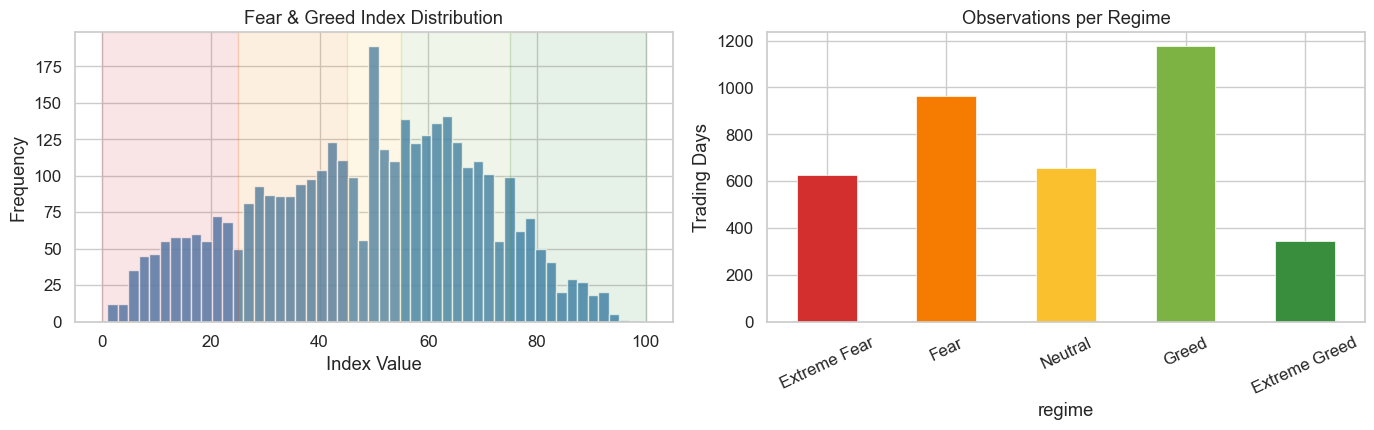


USE_DIRECTION=True  |  direction label distribution:
regime_use
Extreme Fear       626.0
Fear-Falling       587.0
Fear-Rising        375.0
Neutral-Falling    298.0
Neutral-Rising     353.0
Greed-Falling      421.0
Greed-Rising       746.0
Extreme Greed      344.0
Name: days, dtype: float64


In [72]:
fng = pd.read_csv(BASE / 'data' / 'all_fng_csv_4_dec_2025.csv')
fng.columns = ['date', 'fng']
fng['date'] = pd.to_datetime(fng['date'])
fng = fng[fng['fng'] > 0]  # remove weekend/holiday artifacts

# Categorize regime
bins = [0, 25, 45, 55, 75, 100]
fng['regime'] = pd.cut(fng['fng'], bins=bins, labels=REGIME_ORDER, include_lowest=True)

# FNG direction (5-day change)
fng = fng.sort_values('date')
fng['fng_change_5d'] = fng['fng'] - fng['fng'].shift(5)
fng['fng_direction'] = pd.cut(
    fng['fng_change_5d'],
    bins=[-np.inf, -10, 10, np.inf],
    labels=['Falling', 'Stable', 'Rising'])

print(f"Fear & Greed data: {len(fng):,} days  ({fng['date'].min().date()} to {fng['date'].max().date()})\n")
dist = fng['regime'].value_counts().reindex(REGIME_ORDER)
for regime, count in dist.items():
    print(f"  {regime:18s}  {count:5d}  ({count / len(fng) * 100:4.1f}%)")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

fng['fng'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white', alpha=0.85)
for lo, hi, c in zip(bins[:-1], bins[1:], REGIME_COLORS):
    axes[0].axvspan(lo, hi, alpha=0.12, color=c)
axes[0].set_title('Fear & Greed Index Distribution')
axes[0].set_xlabel('Index Value')
axes[0].set_ylabel('Frequency')

dist.plot.bar(axes[1], color=REGIME_COLORS, edgecolor='white', linewidth=0.5)
axes[1].set_title('Observations per Regime')
axes[1].set_ylabel('Trading Days')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

# ── Rolling OLS slope → FNG direction ────────────────────────────────────────
def rolling_fng_slope(series, window):
    slopes = np.full(len(series), np.nan)
    vals = series.values
    x = np.arange(window, dtype=float)
    for i in range(window, len(vals)):
        y = vals[i - window: i]
        slopes[i] = np.polyfit(x, y, 1)[0]
    return pd.Series(slopes, index=series.index)

fng['fng_slope'] = rolling_fng_slope(fng['fng'], SMOOTH_WINDOW)
fng = fng.dropna(subset=['fng_slope'])  # drop warm-up rows (first SMOOTH_WINDOW days have no slope)

def slope_to_dir(slope, threshold):
    d = pd.Series('Stable', index=slope.index)
    d[slope >= threshold] = 'Rising'   # >= so slope==0 isn't Stable when threshold=0
    d[slope < -threshold] = 'Falling'
    return d

fng['direction'] = slope_to_dir(fng['fng_slope'], SLOPE_THRESHOLD)

def build_ext_regime(row):
    base = row['regime']
    if not USE_DIRECTION:
        return str(base)
    if str(base) in ('Extreme Fear', 'Extreme Greed'):
        return str(base)   # extremes: direction less informative
    return f"{base}-{row['direction']}"

fng['regime_ext'] = fng.apply(build_ext_regime, axis=1)

# Choose which regime column the analysis will use
fng['regime_use'] = fng['regime_ext'] if USE_DIRECTION else fng['regime'].astype(str)

EXT_REGIME_ORDER = (
    ['Extreme Fear',
     'Fear-Falling', 'Fear-Stable', 'Fear-Rising',
     'Neutral-Falling', 'Neutral-Stable', 'Neutral-Rising',
     'Greed-Falling', 'Greed-Stable', 'Greed-Rising',
     'Extreme Greed']
    if USE_DIRECTION else REGIME_ORDER
)

print(f'\nUSE_DIRECTION={USE_DIRECTION}  |  direction label distribution:')
print(fng['regime_use'].value_counts().reindex(EXT_REGIME_ORDER).dropna().rename('days'))

## 2. Load Stock Data & Metadata

In [73]:
# Stock metadata
meta = pd.read_csv(BASE / 'us_stocks_500m.csv')[['ticker', 'sector', 'market_cap']]
meta = meta.drop_duplicates(subset='ticker')
print(f"Metadata: {len(meta):,} tickers")

# Stock data from parquets (select columns only)
parquet_files = sorted((BASE / 'stock_training_data_final').glob('batch_*.parquet'))
print(f"Parquet batches: {len(parquet_files)}")

needed_cols = ['date', 'ticker', 'beta_spy', 'vol_std_21', 'roc_21',
               'target_ret_1d', 'target_ret_3d', 'target_ret_5d',
               'target_ret_10d', 'target_ret_21d']
chunks = []
for i, f in enumerate(parquet_files):
    chunks.append(pd.read_parquet(f, columns=needed_cols))
    if (i + 1) % 20 == 0:
        print(f"  Loaded {i + 1}/{len(parquet_files)}...")

stocks = pd.concat(chunks, ignore_index=True)
stocks['date'] = pd.to_datetime(stocks['date']).dt.tz_localize(None).dt.normalize()
print(f"\nStock data: {len(stocks):,.0f} rows, {stocks['ticker'].nunique():,} tickers")
print(f"Date range: {stocks['date'].min().date()} to {stocks['date'].max().date()}")

Metadata: 3,098 tickers
Parquet batches: 59
  Loaded 20/59...
  Loaded 40/59...

Stock data: 4,756,938 rows, 2,908 tickers
Date range: 2018-07-23 to 2025-12-17


In [74]:
# Merge
df = (stocks
      .merge(fng[['date', 'fng', 'regime', 'regime_use', 'fng_direction', 'direction']], on='date', how='inner')
      .merge(meta, on='ticker', how='inner')
      .dropna(subset=['target_ret_1d', 'beta_spy', 'regime']))

# Beta groups
beta_labels = ['Negative', 'Low', 'Market', 'High']
df['beta_group'] = pd.cut(df['beta_spy'],
    bins=[-np.inf, 0, 0.8, 1.2, np.inf], labels=beta_labels)

# Market cap groups
cap_labels = ['Micro', 'Small', 'Mid', 'Large', 'Mega']
df['cap_group'] = pd.cut(df['market_cap'],
    bins=[0, 3e8, 2e9, 1e10, 2e11, np.inf], labels=cap_labels)

# Volatility groups (terciles)
vol_bounds = df['vol_std_21'].quantile([1/3, 2/3]).values
vol_labels = ['Low Vol', 'Med Vol', 'High Vol']
df['vol_group'] = pd.cut(df['vol_std_21'],
    bins=[-np.inf, vol_bounds[0], vol_bounds[1], np.inf], labels=vol_labels)

# Momentum groups (terciles)
mom_bounds = df['roc_21'].quantile([1/3, 2/3]).values
mom_labels = ['Losers', 'Neutral', 'Winners']
df['mom_group'] = pd.cut(df['roc_21'],
    bins=[-np.inf, mom_bounds[0], mom_bounds[1], np.inf], labels=mom_labels)

print(f"Merged dataset: {len(df):,.0f} rows, {df['ticker'].nunique():,} tickers")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nGroup sizes:")
for col, name in [('beta_group', 'Beta'), ('cap_group', 'Cap'),
                   ('vol_group', 'Vol'), ('mom_group', 'Momentum')]:
    print(f"  {name}: {df[col].value_counts().sort_index().to_dict()}")

Merged dataset: 4,512,889 rows, 2,908 tickers
Date range: 2018-07-23 to 2025-12-04

Group sizes:
  Beta: {'Negative': 53331, 'Low': 1439750, 'Market': 1466866, 'High': 1552942}
  Cap: {'Micro': 0, 'Small': 1417243, 'Mid': 1603743, 'Large': 1373240, 'Mega': 118663}
  Vol: {'Low Vol': 1504297, 'Med Vol': 1504295, 'High Vol': 1504297}
  Momentum: {'Losers': 1504297, 'Neutral': 1504295, 'Winners': 1504297}


In [75]:
def regime_table(data, group_col, ret_col, group_order=None, sort_spread=False):
    """Pivot table: mean return (bps) by group x regime, with heatmap."""
    tmp = data.dropna(subset=[ret_col, group_col]).copy()
    tmp['_ret'] = tmp[ret_col] * 10000

    mean_t = (tmp.pivot_table(values='_ret', index=group_col, columns='regime_use',
                              aggfunc='mean', observed=False)
              .reindex(columns=EXT_REGIME_ORDER))
    count_t = (tmp.pivot_table(values='_ret', index=group_col, columns='regime_use',
                               aggfunc='count', observed=False)
               .reindex(columns=EXT_REGIME_ORDER))

    if group_order:
        mean_t  = mean_t.reindex(group_order)
        count_t = count_t.reindex(group_order)

    has_ef = 'Extreme Fear'  in mean_t.columns
    has_eg = 'Extreme Greed' in mean_t.columns
    if has_ef and has_eg:
        mean_t['EF-EG'] = mean_t['Extreme Fear'] - mean_t['Extreme Greed']

    if sort_spread and 'EF-EG' in mean_t.columns:
        order  = mean_t['EF-EG'].sort_values(ascending=False).index
        mean_t  = mean_t.reindex(order)
        count_t = count_t.reindex(order)

    # Styled table — only gradient columns that actually exist
    regime_cols_present = [c for c in EXT_REGIME_ORDER if c in mean_t.columns]
    extra_cols = ['EF-EG'] if 'EF-EG' in mean_t.columns else []
    styled = mean_t.style.background_gradient(
        cmap='RdYlGn', axis=None, subset=regime_cols_present)
    if extra_cols:
        styled = styled.background_gradient(cmap='PuOr', axis=None, subset=extra_cols)
    display(styled.format('{:.1f}'))

    # Heatmap — only existing regime columns (drop EF-EG helper)
    heat_cols = [c for c in EXT_REGIME_ORDER if c in mean_t.columns]
    h = max(len(mean_t) * 0.55, 2.5)
    fig, ax = plt.subplots(figsize=(max(10, len(heat_cols) * 0.9), h))
    sns.heatmap(mean_t[heat_cols], annot=True, fmt='.1f', cmap='RdYlGn', center=0,
                ax=ax, linewidths=0.5, cbar_kws={'label': 'bps'})
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

    return mean_t, count_t


def run_all_horizons(data, group_col, group_order=None, sort_spread=False):
    """Run regime_table for every return horizon."""
    for label, col in HORIZONS.items():
        display(Markdown(f'### {label} Returns'))
        regime_table(data, group_col, col, group_order, sort_spread)

## 3. Overall Returns by Sentiment Regime

### 1-Day Returns

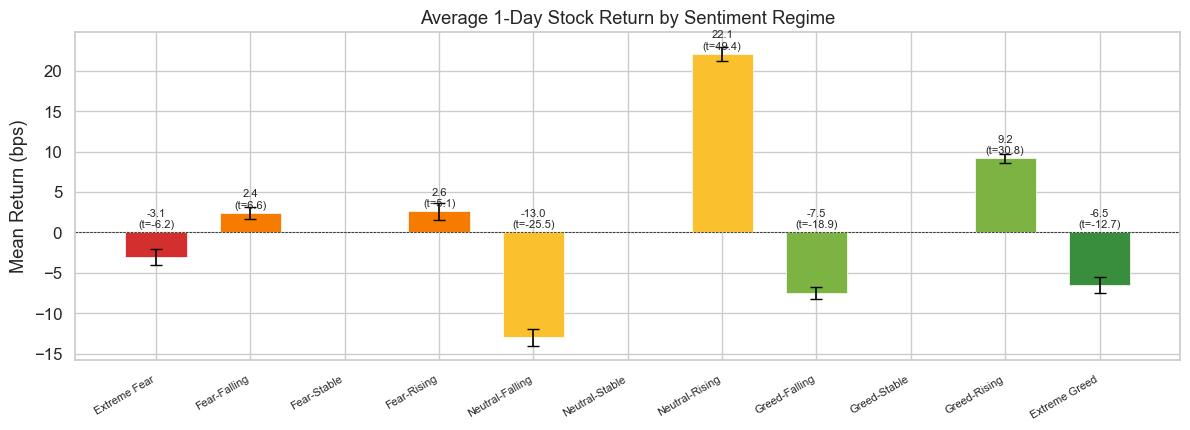

### 3-Day Returns

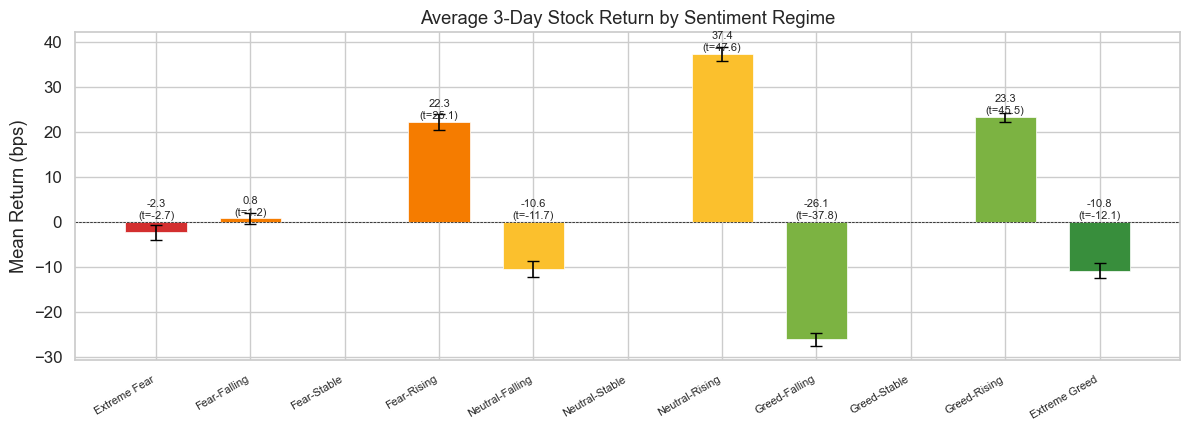

### 5-Day Returns

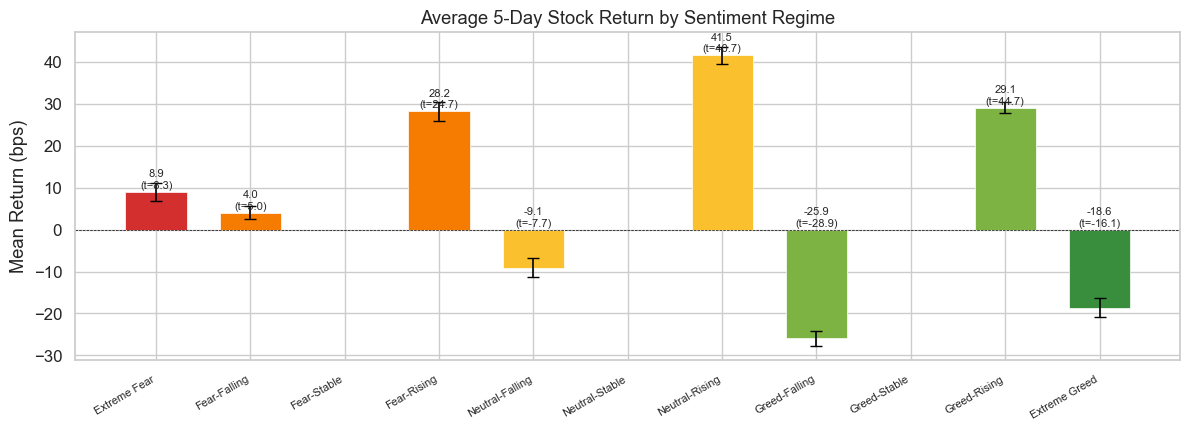

### 10-Day Returns

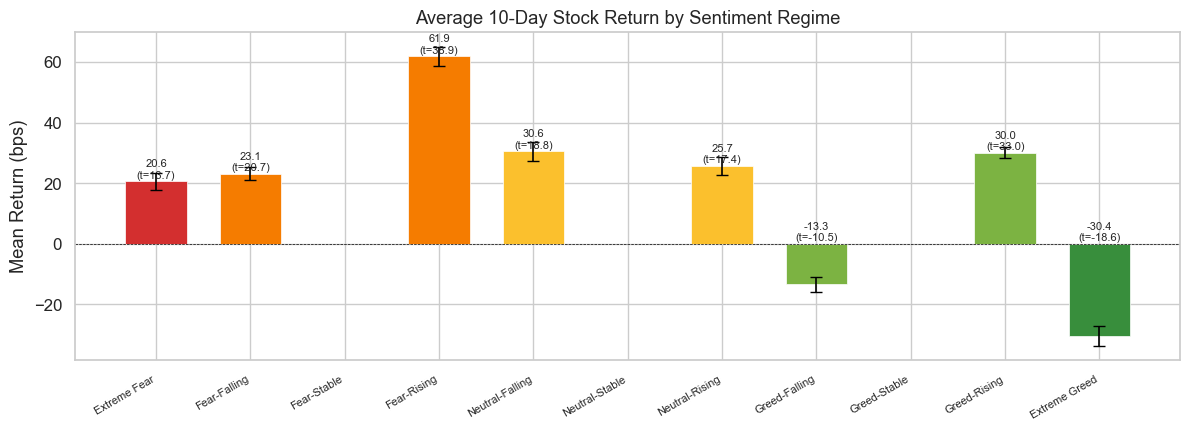

### 21-Day Returns

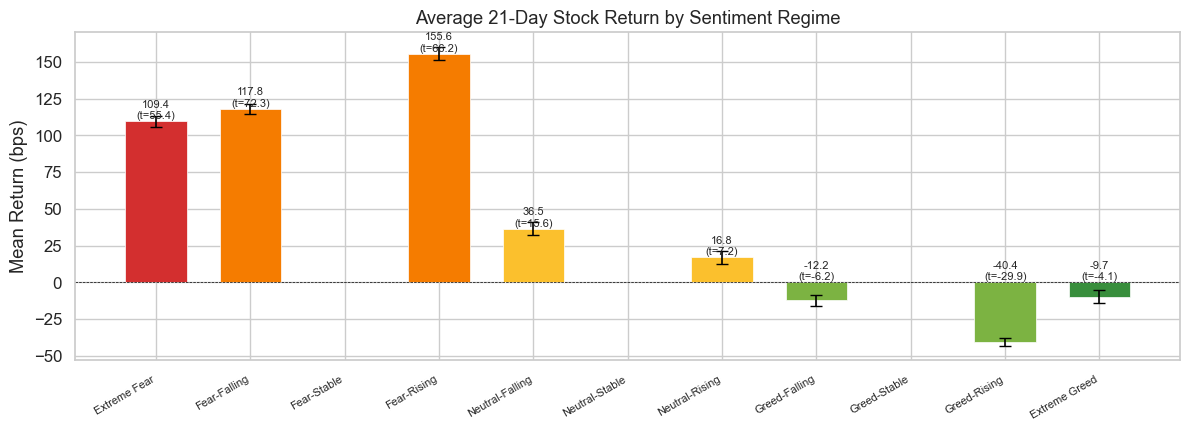

In [76]:
for label, col in HORIZONS.items():
    display(Markdown(f'### {label} Returns'))
    tmp = df.dropna(subset=[col]).copy()
    tmp['_ret'] = tmp[col] * 10000

    overall = tmp.groupby('regime_use', observed=False)['_ret'].agg(
        ['mean', 'count', 'std']).reindex(EXT_REGIME_ORDER)
    overall['se']     = overall['std'] / np.sqrt(overall['count'])
    overall['t_stat'] = overall['mean'] / overall['se']

    n_reg = len(EXT_REGIME_ORDER)
    colors_ext = [REGIME_COLORS_DICT.get(r.split('-')[0], '#888888') for r in EXT_REGIME_ORDER]

    fig, ax = plt.subplots(figsize=(max(10, n_reg * 1.1), 4.5))
    bars = ax.bar(range(n_reg), overall['mean'], color=colors_ext,
                  edgecolor='white', linewidth=0.5, width=0.65)
    ax.errorbar(range(n_reg), overall['mean'], yerr=1.96 * overall['se'],
                fmt='none', color='black', capsize=4, linewidth=1.2)
    ax.set_xticks(range(n_reg))
    ax.set_xticklabels(EXT_REGIME_ORDER, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Mean Return (bps)')
    ax.set_title(f'Average {label} Stock Return by Sentiment Regime')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

    for bar, val, t in zip(bars, overall['mean'], overall['t_stat']):
        if np.isnan(val):
            continue
        ypos = max(val, 0) + 0.3
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f'{val:.1f}\n(t={t:.1f})', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

## 4. Returns by Beta Group

Rolling 252-day beta vs SPY: **Negative** (β < 0) · **Low** (0 ≤ β < 0.8) · **Market** (0.8 ≤ β < 1.2) · **High** (β ≥ 1.2)

### 1-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
beta_group,,,,,,,,,,,,
Negative,-3.6,-3.6,nan,-0.3,-20.3,nan,13.1,0.2,nan,-1.6,16.7,-20.2
Low,-7.6,1.0,nan,4.3,-9.2,nan,19.1,-3.4,nan,6.0,-4.6,-2.9
Market,-9.7,4.7,nan,5.0,-10.4,nan,25.0,-5.4,nan,8.0,-6.5,-3.2
High,7.8,1.9,nan,-1.0,-18.4,nan,22.3,-13.7,nan,13.8,-8.7,16.5


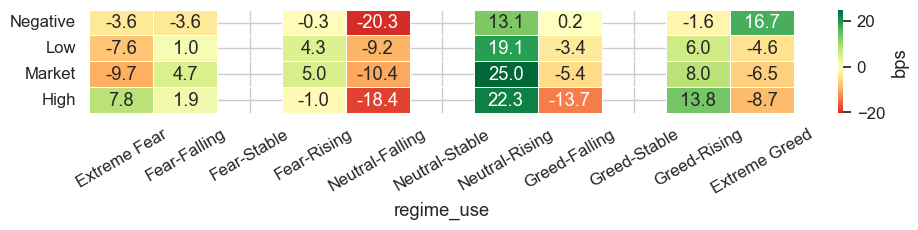

### 3-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
beta_group,,,,,,,,,,,,
Negative,-23.5,-21.0,nan,-2.5,-18.9,nan,22.8,-8.8,nan,-4.0,48.7,-72.2
Low,-16.9,-0.6,nan,22.7,-19.7,nan,35.4,-10.6,nan,12.5,-2.9,-14.0
Market,-19.3,8.4,nan,31.5,-6.3,nan,46.2,-21.3,nan,20.5,-10.0,-9.3
High,29.6,-3.9,nan,14.4,-6.8,nan,30.7,-46.1,nan,37.5,-19.6,49.2


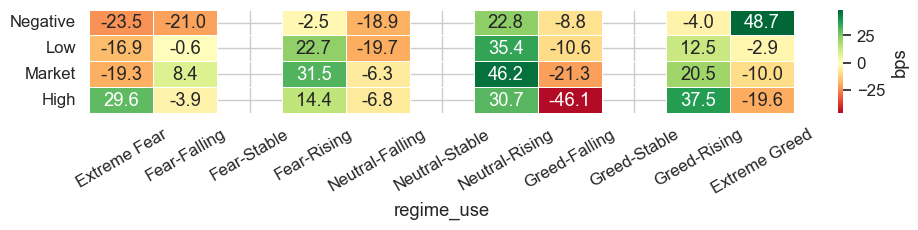

### 5-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
beta_group,,,,,,,,,,,,
Negative,-39.0,-52.9,nan,10.8,-1.6,nan,11.9,14.6,nan,-10.9,55.4,-94.4
Low,-19.5,-1.8,nan,24.8,-25.1,nan,38.3,-5.1,nan,15.9,-2.0,-17.5
Market,-14.8,14.4,nan,41.8,-5.6,nan,54.1,-18.3,nan,27.4,-15.0,0.2
High,62.6,2.4,nan,19.3,0.8,nan,32.8,-54.2,nan,44.7,-36.7,99.3


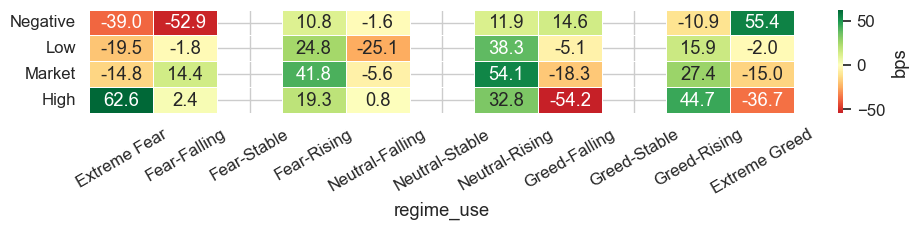

### 10-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
beta_group,,,,,,,,,,,,
Negative,-108.4,-35.0,nan,60.7,13.0,nan,-37.8,12.5,nan,-47.7,120.6,-228.9
Low,-35.5,10.2,nan,33.3,-1.8,nan,26.3,16.0,nan,15.9,3.2,-38.7
Market,-0.2,40.2,nan,87.4,34.3,nan,46.2,-7.0,nan,31.4,-18.1,18.0
High,103.5,22.0,nan,63.8,54.6,nan,6.7,-48.0,nan,44.7,-71.3,174.8


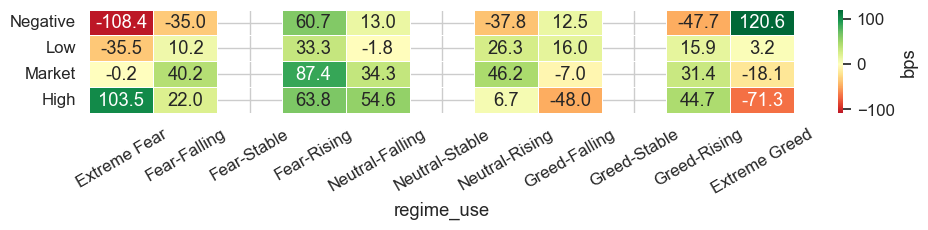

### 21-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
beta_group,,,,,,,,,,,,
Negative,-49.1,84.6,nan,149.8,-122.0,nan,-263.0,-93.8,nan,-176.4,321.5,-370.6
Low,8.0,92.5,nan,105.6,-18.9,nan,-24.8,9.4,nan,-33.7,54.2,-46.2
Market,108.1,147.4,nan,182.5,52.1,nan,67.2,-10.5,nan,-28.9,14.7,93.4
High,222.5,116.1,nan,175.0,72.5,nan,13.0,-31.6,nan,-54.6,-90.1,312.6


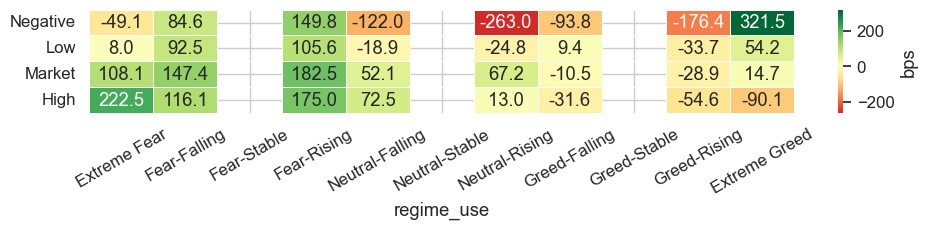

In [77]:
run_all_horizons(df, 'beta_group', group_order=beta_labels)

## 5. Returns by Sector

### 1-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
sector,,,,,,,,,,,,
Technology,8.0,1.5,nan,0.4,-1.7,nan,16.2,-10.9,nan,9.9,-6.5,14.5
Utilities,-1.1,5.1,nan,1.8,-7.1,nan,26.9,-8.4,nan,6.2,-7.5,6.4
Basic Materials,-2.0,2.9,nan,4.7,-8.9,nan,28.7,-5.3,nan,7.1,-8.0,6.0
Healthcare,-1.0,1.5,nan,-0.8,-5.3,nan,12.9,-6.2,nan,6.5,-5.6,4.7
Consumer Cyclical,-8.3,1.7,nan,0.4,-17.5,nan,23.7,-10.6,nan,13.7,-12.1,3.8
Communication Services,-5.5,-2.0,nan,-3.3,-15.5,nan,19.5,-9.9,nan,7.2,-8.9,3.5
Industrials,-4.2,2.8,nan,2.2,-12.8,nan,24.2,-4.0,nan,13.6,-6.8,2.6
Financial Services,-2.3,4.8,nan,3.6,-18.5,nan,24.8,-10.0,nan,9.8,-4.4,2.2
Consumer Defensive,-4.4,2.8,nan,7.0,-11.5,nan,13.5,-9.2,nan,7.2,-2.8,-1.6


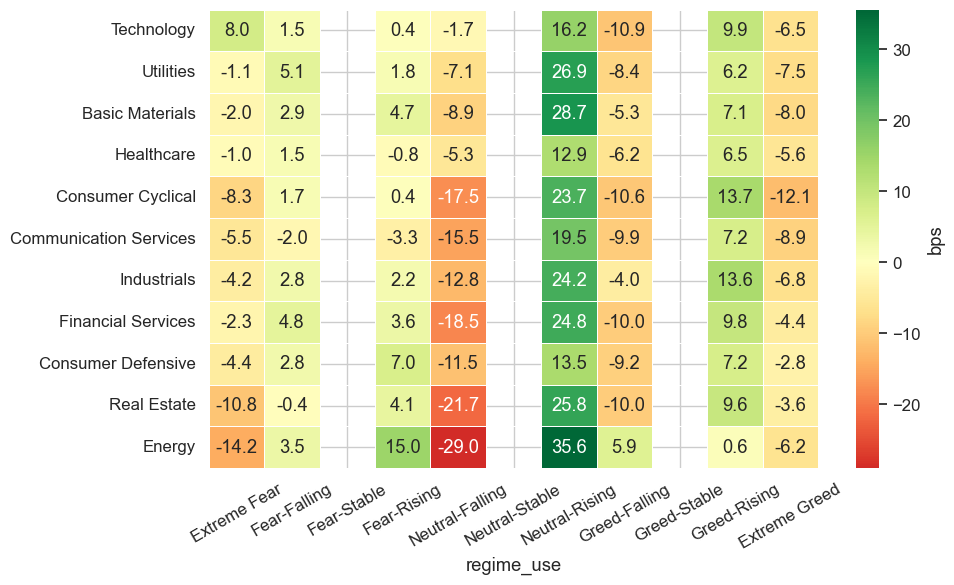

### 3-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
sector,,,,,,,,,,,,
Basic Materials,14.8,-8.7,nan,39.3,0.1,nan,40.4,-15.0,nan,20.0,-25.1,39.9
Technology,25.7,-4.0,nan,17.2,3.7,nan,34.1,-32.2,nan,26.5,-13.9,39.6
Utilities,3.7,17.6,nan,14.6,4.6,nan,36.2,-23.1,nan,13.5,-12.6,16.3
Healthcare,10.9,-8.0,nan,-2.8,-4.6,nan,31.6,-29.2,nan,13.4,-2.0,12.9
Industrials,-5.3,2.1,nan,23.2,3.6,nan,36.8,-17.3,nan,37.5,-14.6,9.3
Energy,-20.1,-4.6,nan,48.2,-53.3,nan,73.5,10.0,nan,5.3,-22.8,2.7
Communication Services,-16.1,-1.6,nan,-0.3,-37.3,nan,35.3,-27.3,nan,17.2,-18.8,2.6
Consumer Cyclical,-20.8,-5.3,nan,33.2,-20.9,nan,32.2,-34.4,nan,35.3,-22.3,1.5
Consumer Defensive,-4.8,2.6,nan,30.8,-23.7,nan,21.9,-23.4,nan,17.6,0.5,-5.3


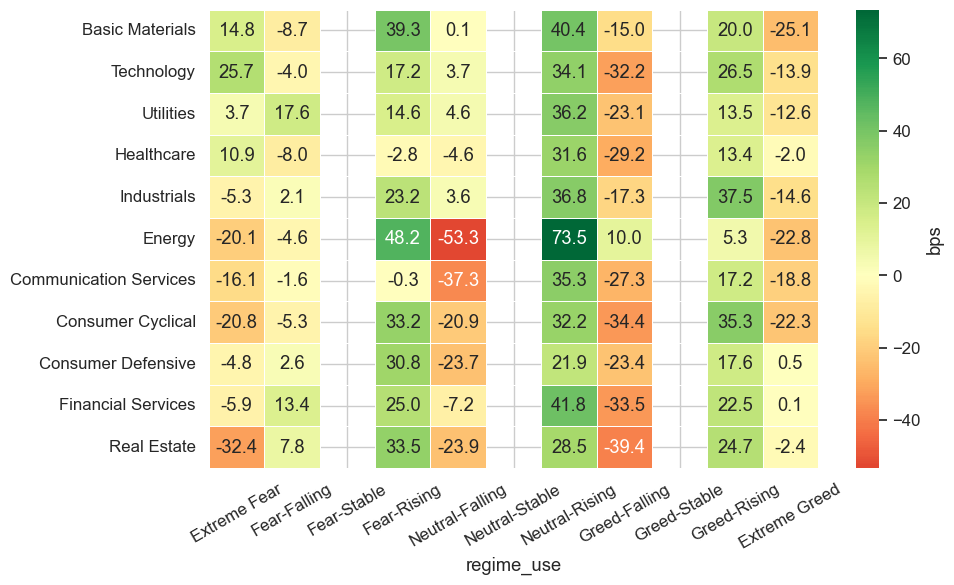

### 5-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
sector,,,,,,,,,,,,
Basic Materials,44.2,-26.0,nan,57.8,13.3,nan,38.7,-3.0,nan,31.9,-51.2,95.4
Technology,48.3,6.8,nan,21.0,-2.1,nan,38.0,-26.1,nan,32.2,-28.2,76.5
Energy,-0.3,-15.5,nan,64.6,-62.2,nan,86.5,21.7,nan,5.2,-45.1,44.8
Healthcare,20.2,-6.9,nan,-1.2,1.6,nan,27.9,-27.9,nan,15.1,-12.9,33.2
Utilities,12.8,26.1,nan,27.7,25.6,nan,32.1,-28.2,nan,16.5,-16.3,29.1
Industrials,9.0,1.7,nan,24.9,12.3,nan,41.3,-11.7,nan,52.2,-19.3,28.2
Communication Services,-15.6,5.2,nan,-0.2,-55.8,nan,39.5,-34.3,nan,17.2,-26.2,10.6
Consumer Cyclical,-19.4,-1.9,nan,39.3,-23.8,nan,38.9,-41.5,nan,43.4,-27.2,7.8
Financial Services,3.6,21.3,nan,34.3,-8.0,nan,53.1,-34.4,nan,26.0,-0.8,4.4


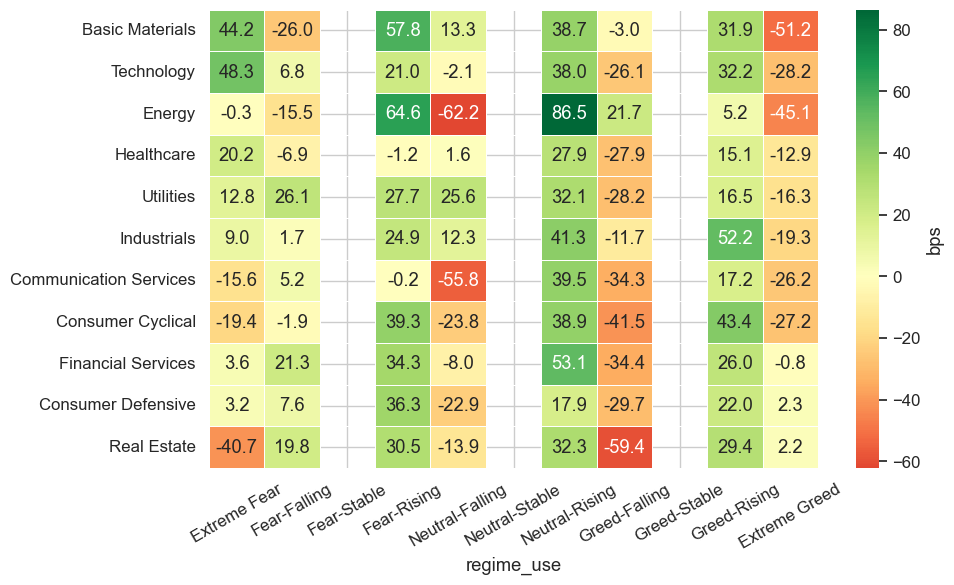

### 10-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
sector,,,,,,,,,,,,
Basic Materials,72.9,10.0,nan,112.4,78.8,nan,20.6,16.5,nan,33.6,-106.0,178.9
Technology,67.7,40.0,nan,48.7,44.4,nan,10.6,17.5,nan,33.6,-43.5,111.1
Energy,11.6,5.7,nan,136.1,-42.8,nan,81.6,37.2,nan,-18.8,-94.4,106.1
Utilities,32.2,66.4,nan,62.0,83.7,nan,2.4,-2.5,nan,6.7,-38.3,70.5
Industrials,25.7,14.4,nan,56.5,52.9,nan,21.2,27.1,nan,73.6,-20.5,46.2
Healthcare,16.7,-3.9,nan,34.2,15.3,nan,23.1,-28.7,nan,17.9,-24.4,41.1
Financial Services,30.9,50.9,nan,62.4,41.6,nan,41.6,-32.8,nan,26.8,-7.3,38.3
Consumer Defensive,37.0,-1.3,nan,54.6,21.6,nan,14.1,-34.4,nan,15.6,5.8,31.2
Communication Services,-16.5,17.0,nan,12.3,-38.6,nan,24.6,-52.7,nan,-0.4,-35.5,19.0


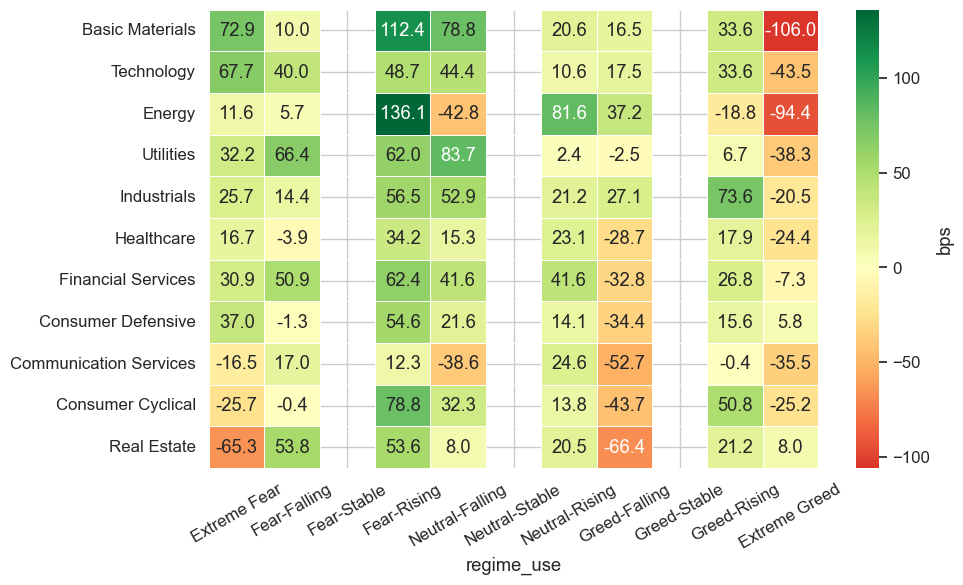

### 21-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
sector,,,,,,,,,,,,
Basic Materials,182.8,163.1,nan,242.3,107.7,nan,5.9,39.2,nan,-42.9,-117.1,299.9
Energy,156.5,133.5,nan,256.1,4.7,nan,63.6,-52.9,nan,-144.5,-76.2,232.7
Technology,184.3,106.1,nan,93.0,102.6,nan,51.3,94.3,nan,-37.3,-23.2,207.5
Utilities,137.2,148.7,nan,155.9,63.8,nan,-38.8,23.2,nan,-15.0,-22.9,160.1
Consumer Defensive,139.7,40.8,nan,155.6,-36.6,nan,15.2,-54.6,nan,-35.9,10.8,128.9
Consumer Cyclical,75.2,63.2,nan,199.2,-3.3,nan,3.1,-57.7,nan,-39.7,-15.5,90.7
Industrials,112.4,105.4,nan,166.7,61.3,nan,34.6,44.6,nan,39.9,25.0,87.4
Financial Services,111.5,190.4,nan,172.0,86.2,nan,34.7,-39.9,nan,-55.9,29.4,82.1
Healthcare,74.4,88.6,nan,79.0,-9.4,nan,-31.5,-39.6,nan,-32.2,1.2,73.1


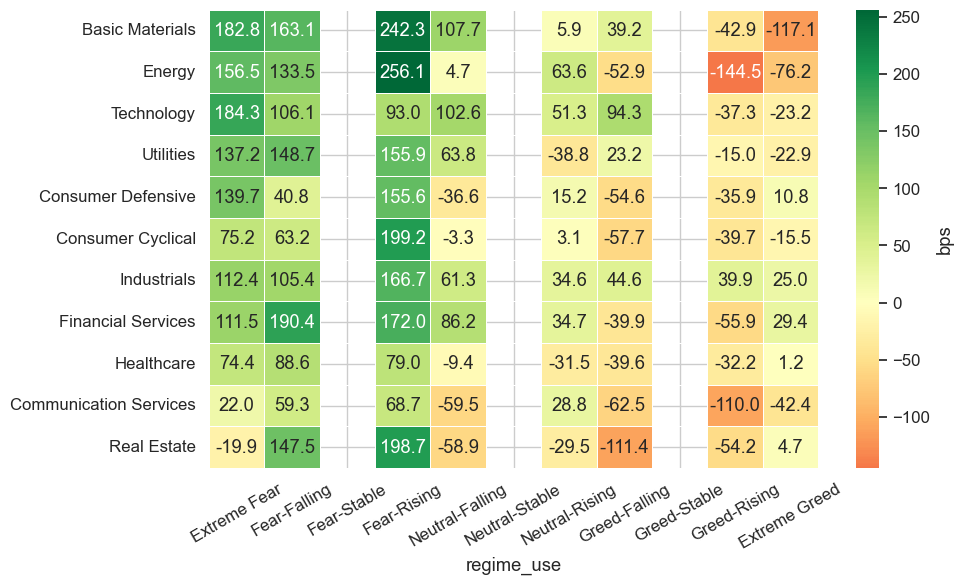

In [78]:
run_all_horizons(df, 'sector', sort_spread=True)

## 6. Returns by Market Cap

**Mega** > $200B · **Large** $10B–$200B · **Mid** $2B–$10B · **Small** $300M–$2B · **Micro** < $300M

*Note: Market cap is a point-in-time snapshot, not historical.*

### 1-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
cap_group,,,,,,,,,,,,
Micro,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Small,-7.9,-2.0,nan,-2.6,-19.7,nan,21.2,-10.9,nan,8.7,-11.2,3.3
Mid,-2.7,3.5,nan,3.7,-13.9,nan,24.2,-6.7,nan,9.4,-8.8,6.2
Large,0.7,5.1,nan,6.4,-6.2,nan,21.2,-5.6,nan,9.4,0.1,0.7
Mega,4.6,9.0,nan,6.6,0.6,nan,15.6,1.6,nan,8.6,4.3,0.3


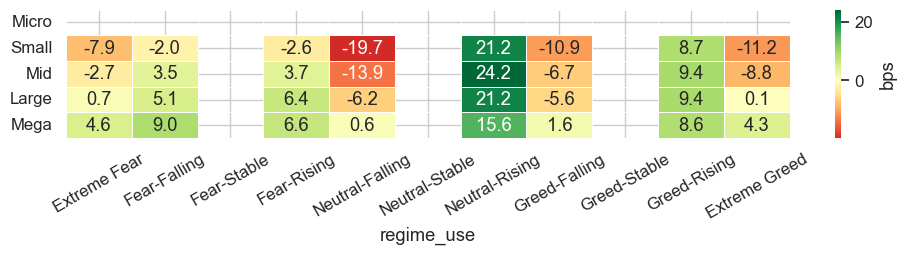

### 3-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
cap_group,,,,,,,,,,,,
Micro,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Small,-16.4,-11.9,nan,8.2,-23.3,nan,36.1,-37.7,nan,20.4,-23.1,6.7
Mid,-0.7,3.9,nan,26.4,-10.6,nan,42.4,-26.4,nan,24.4,-15.7,15.0
Large,8.1,9.0,nan,31.3,-0.1,nan,34.0,-16.1,nan,24.7,5.1,3.0
Mega,22.0,15.8,nan,30.7,18.3,nan,23.1,1.9,nan,27.1,14.7,7.3


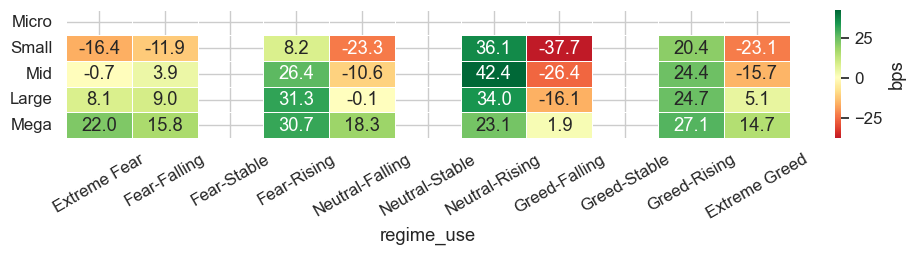

### 5-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
cap_group,,,,,,,,,,,,
Micro,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Small,-13.0,-17.0,nan,7.0,-31.3,nan,38.7,-40.1,nan,22.4,-42.5,29.5
Mid,11.0,9.5,nan,34.8,-9.3,nan,49.8,-27.0,nan,30.7,-23.7,34.7
Large,25.5,17.4,nan,41.5,9.8,nan,36.7,-13.3,nan,32.9,8.4,17.1
Mega,47.9,30.3,nan,37.6,38.5,nan,19.1,17.2,nan,41.7,19.8,28.1


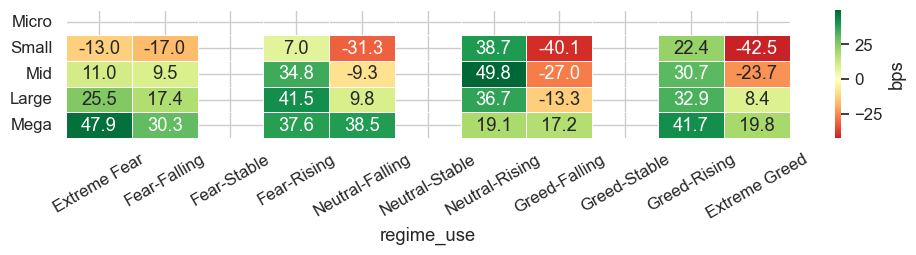

### 10-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
cap_group,,,,,,,,,,,,
Micro,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Small,-18.5,-25.0,nan,28.3,-16.4,nan,13.6,-34.7,nan,13.2,-77.0,58.5
Mid,25.2,33.5,nan,72.5,31.6,nan,36.5,-12.3,nan,34.1,-37.3,62.5
Large,49.3,56.3,nan,84.4,70.6,nan,26.4,2.0,nan,39.9,18.1,31.2
Mega,86.6,82.4,nan,58.7,109.6,nan,17.1,57.4,nan,63.1,52.9,33.7


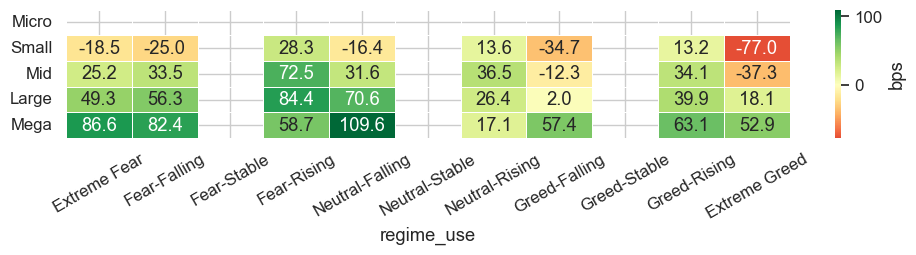

### 21-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
cap_group,,,,,,,,,,,,
Micro,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Small,19.7,47.5,nan,76.7,-37.4,nan,-27.5,-58.8,nan,-95.6,-93.5,113.2
Mid,121.1,142.9,nan,173.4,50.2,nan,36.5,-9.9,nan,-41.3,-7.6,128.7
Large,177.2,156.3,nan,215.3,87.6,nan,33.9,21.6,nan,7.6,57.4,119.8
Mega,217.4,185.8,nan,165.0,134.6,nan,77.9,130.5,nan,75.3,173.6,43.8


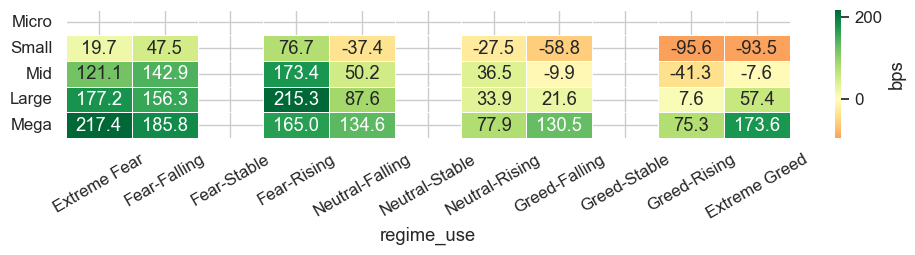

In [79]:
run_all_horizons(df, 'cap_group', group_order=cap_labels)

## 7. Returns by Volatility Group

Stocks split into terciles by 21-day realized volatility (`vol_std_21`): **Low Vol** · **Med Vol** · **High Vol**

### 1-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
vol_group,,,,,,,,,,,,
Low Vol,-4.4,1.5,nan,-0.1,-10.0,nan,16.1,-5.9,nan,5.6,-3.5,-0.9
Med Vol,-2.2,1.5,nan,-0.6,-11.9,nan,25.0,-8.9,nan,8.6,-7.7,5.5
High Vol,-3.1,4.5,nan,6.7,-17.2,nan,24.4,-8.5,nan,13.8,-11.0,7.9


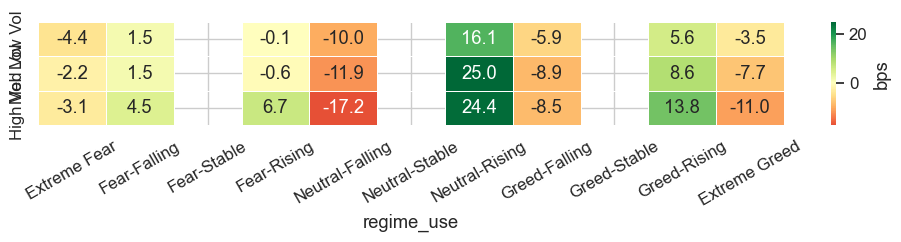

### 3-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
vol_group,,,,,,,,,,,,
Low Vol,-2.3,7.3,nan,3.8,-34.7,nan,20.3,-16.3,nan,11.4,-1.5,-0.7
Med Vol,-1.4,1.4,nan,20.3,0.3,nan,34.8,-30.8,nan,21.4,-9.6,8.2
High Vol,-3.0,-8.1,nan,35.1,4.2,nan,53.7,-36.4,nan,38.6,-31.1,28.0


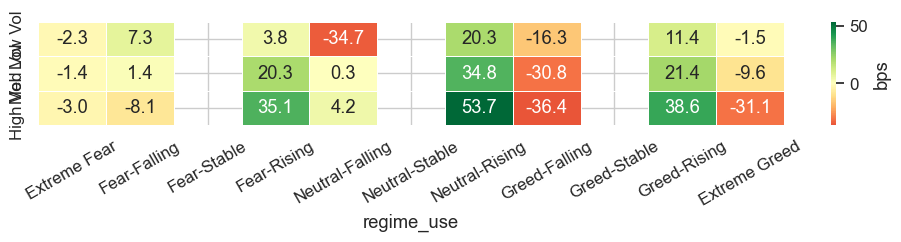

### 5-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
vol_group,,,,,,,,,,,,
Low Vol,3.2,12.0,nan,2.1,-52.2,nan,14.7,-20.1,nan,13.3,-1.0,4.2
Med Vol,3.0,3.8,nan,23.5,5.3,nan,25.5,-28.7,nan,28.9,-14.5,17.5
High Vol,17.0,-5.5,nan,47.8,22.4,nan,78.2,-31.8,nan,46.7,-59.3,76.4


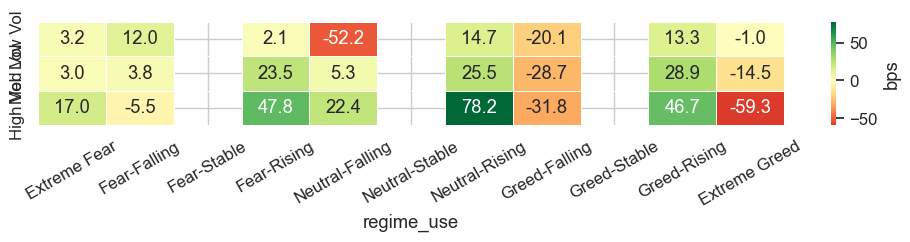

### 10-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
vol_group,,,,,,,,,,,,
Low Vol,8.0,22.6,nan,-5.5,-41.8,nan,-36.2,-20.6,nan,13.3,-2.9,10.9
Med Vol,-17.5,25.1,nan,15.0,49.2,nan,10.0,-15.0,nan,34.0,-21.5,4.0
High Vol,58.8,21.5,nan,138.7,88.9,nan,91.1,0.8,nan,44.3,-97.2,156.0


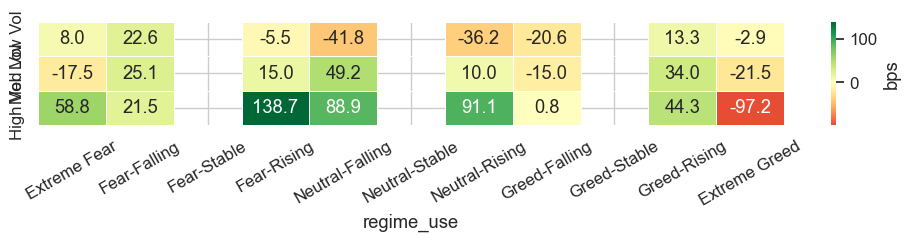

### 21-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
vol_group,,,,,,,,,,,,
Low Vol,37.4,105.1,nan,7.0,-108.0,nan,-157.0,-67.8,nan,-44.8,14.0,23.4
Med Vol,33.0,125.8,nan,67.2,71.9,nan,28.5,-4.5,nan,-30.4,-4.3,37.4
High Vol,211.8,123.9,nan,313.4,154.7,nan,149.5,68.9,nan,-46.4,-64.6,276.4


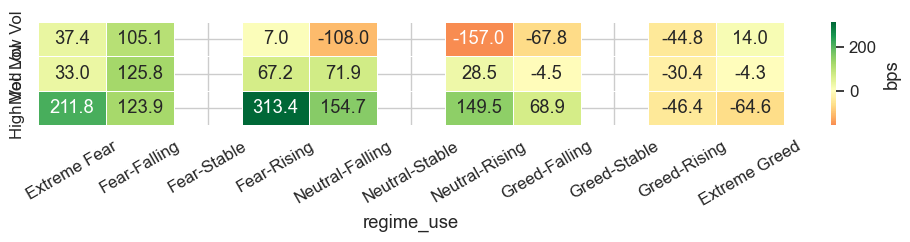

In [80]:
run_all_horizons(df, 'vol_group', group_order=vol_labels)

## 8. Returns by Momentum Group

Stocks split into terciles by 21-day rate of change (`roc_21`): **Losers** · **Neutral** · **Winners**

### 1-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
mom_group,,,,,,,,,,,,
Losers,0.8,1.2,nan,2.7,-9.5,nan,32.2,-7.2,nan,8.2,2.2,-1.4
Neutral,-7.9,3.5,nan,0.8,-10.7,nan,20.5,-7.4,nan,8.4,-2.9,-5.0
Winners,-10.2,3.2,nan,4.4,-20.2,nan,18.0,-7.9,nan,10.1,-12.1,1.9


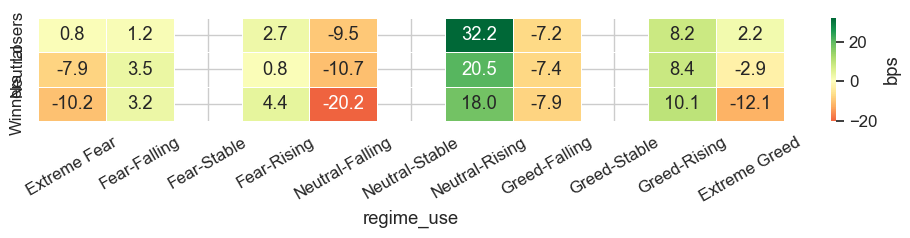

### 3-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
mom_group,,,,,,,,,,,,
Losers,4.5,-3.3,nan,22.8,-9.2,nan,41.0,-20.3,nan,26.6,13.3,-8.8
Neutral,-10.3,6.4,nan,20.4,-11.6,nan,32.9,-24.4,nan,20.2,2.3,-12.6
Winners,-15.4,0.4,nan,23.8,-11.1,nan,38.9,-32.9,nan,24.2,-28.8,13.4


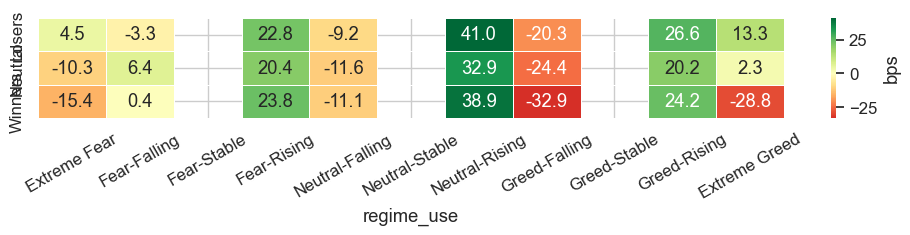

### 5-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
mom_group,,,,,,,,,,,,
Losers,20.3,5.5,nan,0.5,4.1,nan,34.1,-22.0,nan,38.3,11.5,8.8
Neutral,-4.2,12.1,nan,24.1,-19.8,nan,32.1,-26.6,nan,26.8,3.8,-8.0
Winners,-13.5,-12.3,nan,60.3,-12.2,nan,52.6,-28.2,nan,27.0,-45.6,32.0


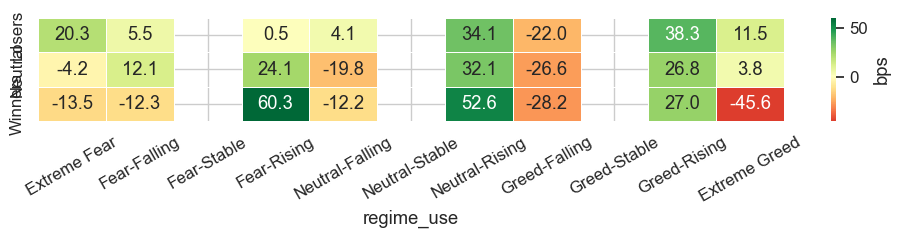

### 10-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
mom_group,,,,,,,,,,,,
Losers,39.8,36.7,nan,24.1,52.1,nan,-36.7,-22.7,nan,43.5,7.0,32.7
Neutral,-8.8,31.5,nan,43.7,10.5,nan,4.1,-18.9,nan,33.2,3.9,-12.7
Winners,-4.6,-20.2,nan,119.4,28.6,nan,74.8,1.0,nan,22.7,-68.9,64.3


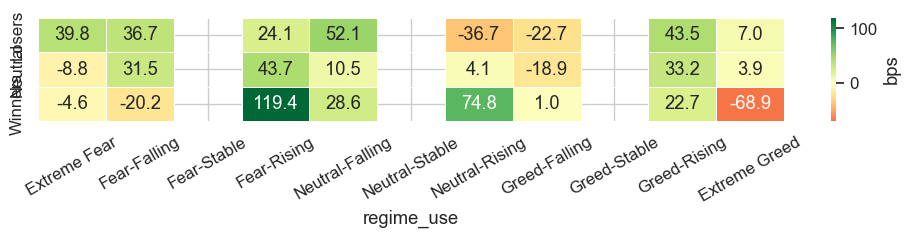

### 21-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
mom_group,,,,,,,,,,,,
Losers,177.9,142.3,nan,143.7,7.7,nan,-155.3,-3.5,nan,-30.0,80.3,97.6
Neutral,14.0,121.7,nan,102.9,15.6,nan,-36.5,-31.8,nan,-21.7,34.3,-20.3
Winners,-7.6,57.7,nan,224.0,98.2,nan,147.2,3.7,nan,-57.2,-72.9,65.3


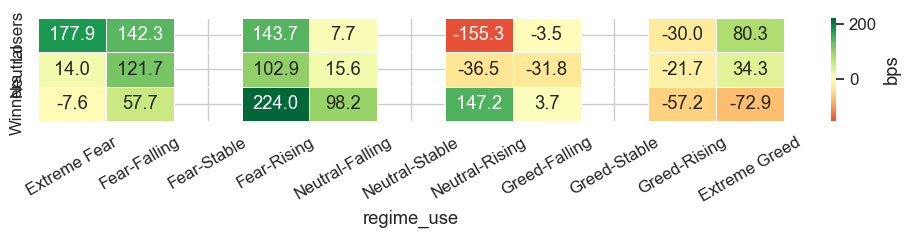

In [81]:
run_all_horizons(df, 'mom_group', group_order=mom_labels)

## 9. Return Distribution by Regime

Beyond mean returns: standard deviation, skewness, hit rate (% positive), and tail percentiles.

### 1-Day Returns

,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed
Mean (bps),-3.1,2.4,nan,2.6,-13.0,nan,22.1,-7.5,nan,9.2,-6.5
Median (bps),8.5,3.2,nan,5.1,-4.0,nan,14.6,-3.6,nan,5.2,-3.5
Std (bps),422.9,304.4,nan,336.8,301.4,nan,313.8,282.8,nan,300.6,266.4
Skew,-1.2,-1.0,nan,-0.7,0.6,nan,12.7,0.3,nan,2.4,0.4
Hit Rate %,51.2,50.4,nan,50.7,48.2,nan,53.0,48.1,nan,50.9,47.9
5th Pctl,-597.2,-421.1,nan,-476.9,-455.5,nan,-393.8,-384.9,nan,-383.8,-362.4
95th Pctl,553.9,417.2,nan,474.6,394.9,nan,457.0,356.6,nan,411.5,337.7
N,722176.0,714135.0,nan,436573.0,350503.0,nan,491551.0,508146.0,nan,1021672.0,268133.0


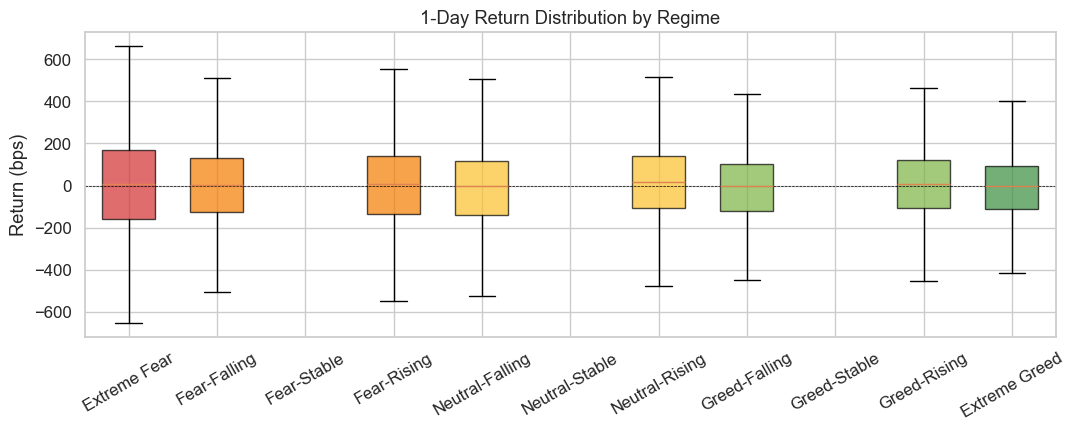

### 3-Day Returns

,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed
Mean (bps),-2.3,0.8,nan,22.3,-10.6,nan,37.4,-26.1,nan,23.3,-10.8
Median (bps),37.4,9.1,nan,26.0,-1.1,nan,33.4,-16.3,nan,15.1,-4.8
Std (bps),716.8,522.6,nan,586.8,537.2,nan,550.1,492.9,nan,517.2,464.5
Skew,-1.3,-0.6,nan,-0.2,0.3,nan,7.3,0.3,nan,2.1,0.2
Hit Rate %,53.7,51.0,nan,52.9,49.3,nan,54.0,47.2,nan,51.9,48.7
5th Pctl,-1070.9,-755.1,nan,-830.1,-797.7,nan,-735.5,-712.9,nan,-670.3,-650.5
95th Pctl,935.5,722.4,nan,862.6,742.4,nan,804.9,626.3,nan,743.1,597.9
N,722171.0,714135.0,nan,436569.0,350503.0,nan,491551.0,508146.0,nan,1021672.0,268133.0


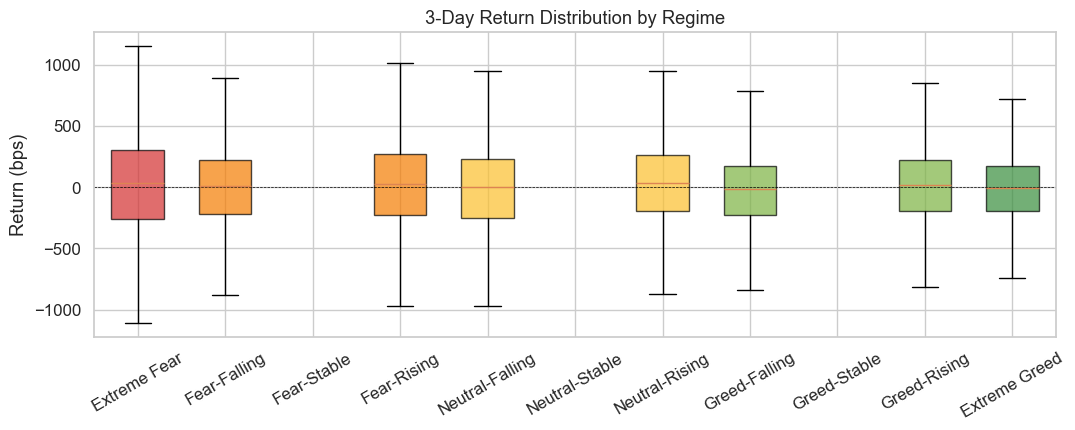

### 5-Day Returns

,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed
Mean (bps),8.9,4.0,nan,28.2,-9.1,nan,41.5,-25.9,nan,29.1,-18.6
Median (bps),63.4,19.0,nan,49.0,0.0,nan,36.6,-12.4,nan,19.5,-8.5
Std (bps),919.8,675.0,nan,753.0,697.0,nan,714.7,637.5,nan,657.5,597.7
Skew,-1.4,-0.6,nan,0.1,0.3,nan,4.6,0.5,nan,2.0,-0.0
Hit Rate %,55.0,51.8,nan,54.3,49.6,nan,53.3,48.3,nan,51.9,48.5
5th Pctl,-1357.0,-996.3,nan,-1122.9,-1036.6,nan,-988.6,-935.6,nan,-873.4,-855.0
95th Pctl,1203.4,938.5,nan,1091.2,1003.2,nan,1068.1,830.3,nan,955.0,780.7
N,722162.0,714135.0,nan,436564.0,350503.0,nan,491551.0,508146.0,nan,1021672.0,268133.0


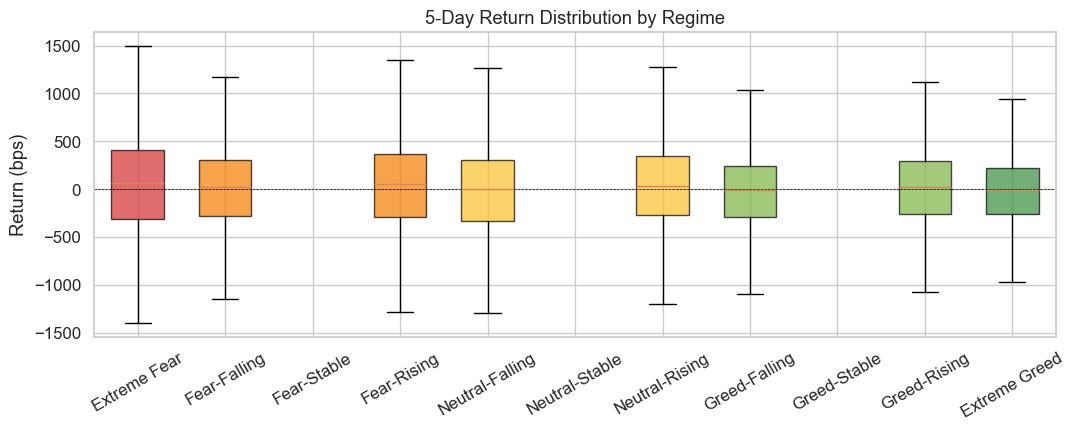

### 10-Day Returns

,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed
Mean (bps),20.6,23.1,nan,61.9,30.6,nan,25.7,-13.3,nan,30.0,-30.4
Median (bps),128.7,49.5,nan,86.2,27.2,nan,21.6,-6.2,nan,25.6,-10.9
Std (bps),1273.3,941.7,nan,1046.4,961.2,nan,1034.2,899.8,nan,919.9,844.1
Skew,-1.9,-0.5,nan,0.2,0.3,nan,3.3,0.5,nan,1.5,-0.0
Hit Rate %,57.3,53.4,nan,55.3,51.7,nan,51.2,49.3,nan,51.7,48.9
5th Pctl,-1915.4,-1382.5,nan,-1564.8,-1377.7,nan,-1463.4,-1308.3,nan,-1282.3,-1254.0
95th Pctl,1638.4,1339.0,nan,1587.8,1445.8,nan,1514.6,1255.4,nan,1338.2,1128.7
N,722123.0,714135.0,nan,433434.0,350503.0,nan,491551.0,508146.0,nan,1021672.0,268133.0


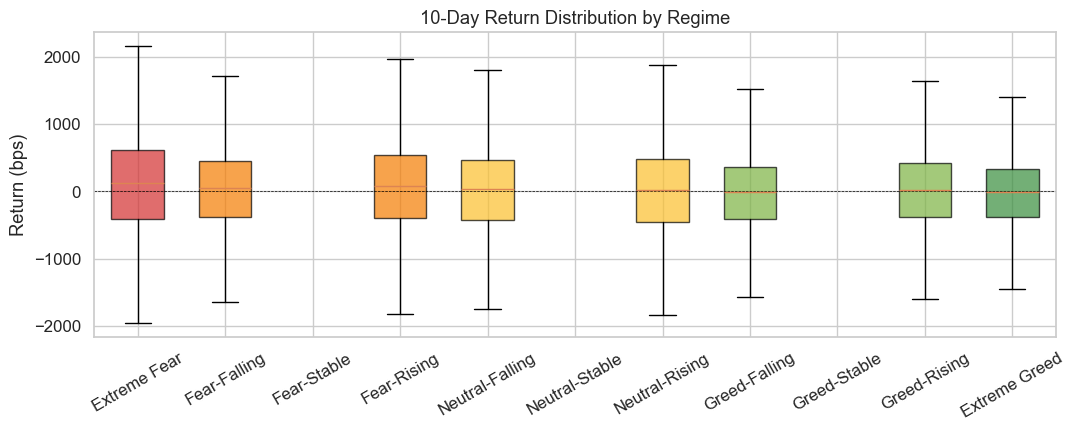

### 21-Day Returns

,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed
Mean (bps),109.4,117.8,nan,155.6,36.5,nan,16.8,-12.2,nan,-40.4,-9.7
Median (bps),190.7,159.2,nan,170.7,47.1,nan,82.2,27.9,nan,-22.1,23.3
Std (bps),1644.6,1377.9,nan,1542.0,1383.1,nan,1633.2,1391.7,nan,1367.1,1235.8
Skew,-0.6,-0.5,nan,-0.3,0.9,nan,-0.3,-0.1,nan,0.5,0.1
Hit Rate %,57.1,57.3,nan,57.2,52.0,nan,53.5,51.2,nan,48.8,51.1
5th Pctl,-2408.9,-1972.3,nan,-2146.1,-2019.3,nan,-2242.3,-2088.6,nan,-2038.9,-1828.8
95th Pctl,2399.5,2068.3,nan,2421.4,2031.0,nan,2114.7,1904.9,nan,1907.7,1700.5
N,692837.0,714114.0,nan,430753.0,350503.0,nan,491551.0,508146.0,nan,1021672.0,268133.0


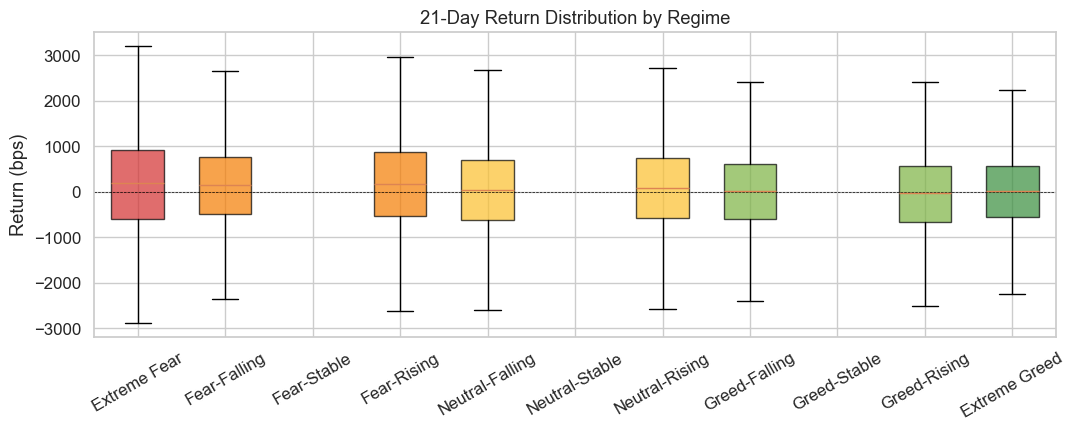

In [82]:
for label, col in HORIZONS.items():
    display(Markdown(f'### {label} Returns'))
    tmp = df.dropna(subset=[col]).copy()
    tmp['_ret'] = tmp[col] * 10000

    grouped = tmp.groupby('regime_use', observed=False)['_ret']
    stats = pd.DataFrame(index=EXT_REGIME_ORDER)
    stats['Mean (bps)']  = grouped.mean()
    stats['Median (bps)']= grouped.median()
    stats['Std (bps)']   = grouped.std()
    stats['Skew']        = grouped.apply(lambda x: x.skew())
    stats['Hit Rate %']  = grouped.apply(lambda x: (x > 0).mean() * 100)
    stats['5th Pctl']    = grouped.apply(lambda x: x.quantile(0.05))
    stats['95th Pctl']   = grouped.apply(lambda x: x.quantile(0.95))
    stats['N']           = grouped.count()
    stats = stats.T
    display(stats.style.format('{:.1f}'))

    # Box plot
    fig, ax = plt.subplots(figsize=(max(10, len(EXT_REGIME_ORDER) * 1.0), 4.5))
    box_data = [tmp[tmp['regime_use'] == r]['_ret'].dropna() for r in EXT_REGIME_ORDER]
    bp = ax.boxplot(box_data, labels=EXT_REGIME_ORDER, patch_artist=True,
                    showfliers=False, widths=0.6)
    colors_ext = [REGIME_COLORS_DICT.get(r.split('-')[0], '#888888') for r in EXT_REGIME_ORDER]
    for patch, c in zip(bp['boxes'], colors_ext):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_title(f'{label} Return Distribution by Regime')
    ax.set_ylabel('Return (bps)')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

## 10. FNG Direction Analysis

FNG direction = 5-day change in Fear & Greed Index:
**Falling** (Δ < −10) · **Stable** (−10 ≤ Δ ≤ +10) · **Rising** (Δ > +10)

Shows whether the *direction* of sentiment matters beyond its level.

### 1-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
fng_direction,,,,,,,,,,,,
Falling,-25.1,-25.0,nan,-45.5,-2.0,nan,27.4,-10.3,nan,1.4,nan,nan
Stable,11.3,17.0,nan,13.6,-25.1,nan,15.9,-8.4,nan,7.4,-8.0,19.2
Rising,-28.5,-12.2,nan,-2.5,31.1,nan,39.7,0.8,nan,16.8,-0.2,-28.3


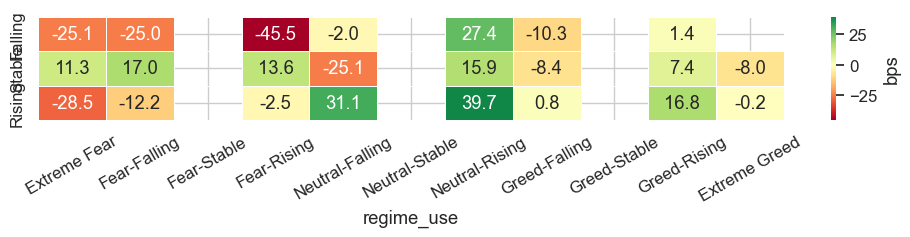

### 3-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
fng_direction,,,,,,,,,,,,
Falling,-43.0,-2.5,nan,-7.8,-13.0,nan,22.3,-33.6,nan,-51.8,nan,nan
Stable,30.7,12.6,nan,31.9,-37.7,nan,26.9,-27.0,nan,25.2,-14.1,44.8
Rising,-131.8,-51.7,nan,11.5,139.8,nan,93.8,-12.3,nan,29.6,3.4,-135.2


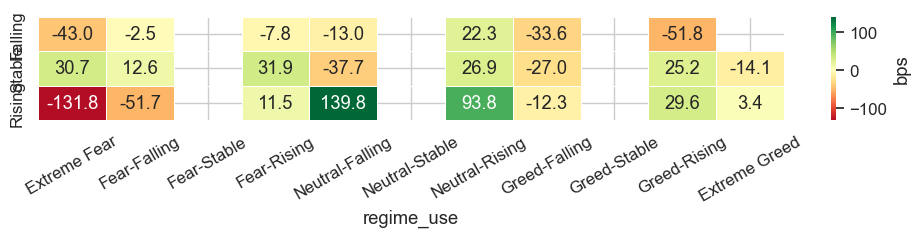

### 5-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
fng_direction,,,,,,,,,,,,
Falling,-39.8,7.5,nan,8.8,14.5,nan,6.3,-71.8,nan,-66.2,nan,nan
Stable,48.5,13.1,nan,29.3,-48.8,nan,33.7,-10.1,nan,34.9,-21.9,70.3
Rising,-147.2,-49.1,nan,35.3,160.2,nan,110.8,-60.5,nan,24.8,-4.5,-142.7


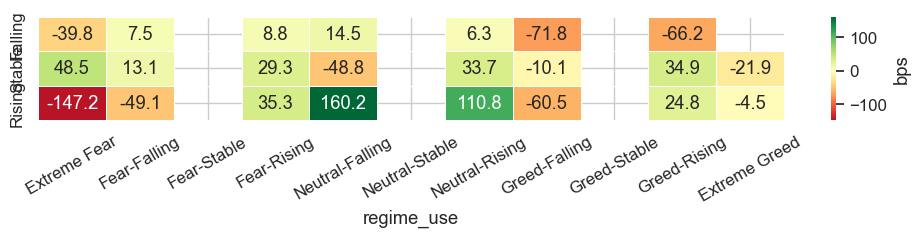

### 10-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
fng_direction,,,,,,,,,,,,
Falling,-141.5,-25.9,nan,41.8,6.1,nan,-177.4,-52.7,nan,-107.6,nan,nan
Stable,94.1,53.5,nan,56.0,-3.4,nan,39.8,5.2,nan,28.2,-30.7,124.8
Rising,248.1,-25.0,nan,89.9,258.9,nan,202.0,-71.1,nan,60.0,-28.9,277.0


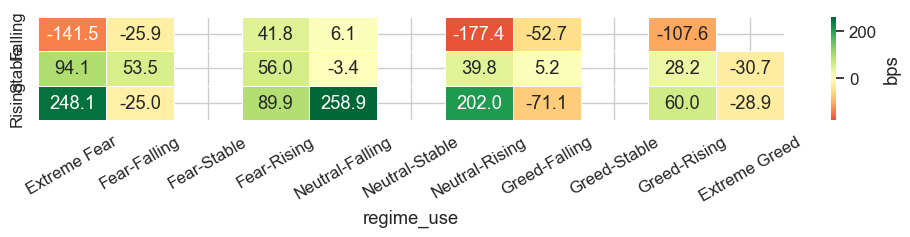

### 21-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed,EF-EG
fng_direction,,,,,,,,,,,,
Falling,-22.1,17.2,nan,-112.3,56.4,nan,-283.6,-7.6,nan,-106.2,nan,nan
Stable,156.4,160.4,nan,225.5,-43.3,nan,38.1,19.6,nan,-47.9,-24.1,180.5
Rising,477.0,118.9,nan,100.0,427.5,nan,275.9,-199.7,nan,-2.9,52.4,424.5


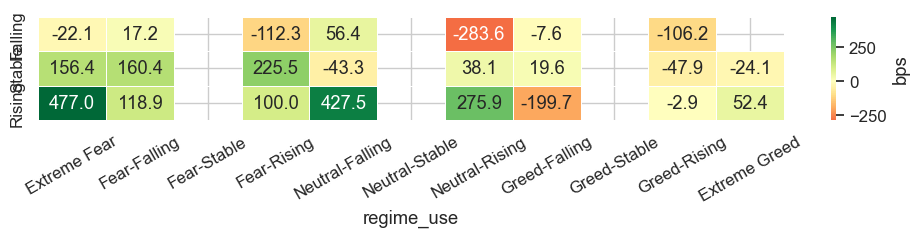

In [83]:
fng_dir_labels = ['Falling', 'Stable', 'Rising']
run_all_horizons(df.dropna(subset=['fng_direction']), 'fng_direction',
                 group_order=fng_dir_labels)

## 11. Long/Short Factor Spreads by Regime

For each sentiment regime, the return spread between long and short sides of three factors:
- **High Beta − Low Beta**: market risk premium
- **Winners − Losers**: momentum premium
- **High Vol − Low Vol**: volatility premium

### 1-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed
High Beta - Low Beta,15.4,0.8,nan,-5.3,-9.2,nan,3.2,-10.3,nan,7.7,-4.0
Winners - Losers,-11.0,2.0,nan,1.6,-10.7,nan,-14.2,-0.6,nan,1.9,-14.4
High Vol - Low Vol,1.3,3.0,nan,6.8,-7.2,nan,8.3,-2.6,nan,8.2,-7.5


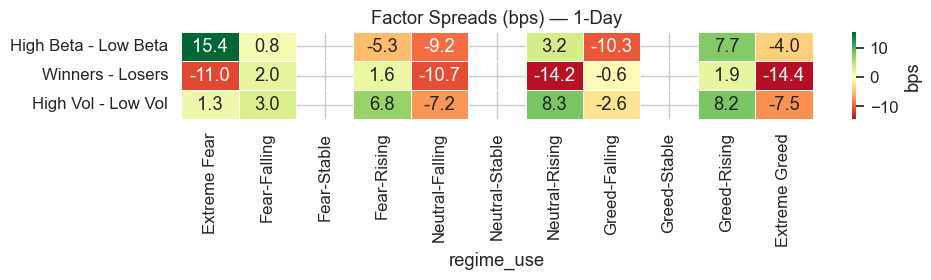

### 3-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed
High Beta - Low Beta,46.5,-3.3,nan,-8.3,12.9,nan,-4.7,-35.6,nan,25.0,-16.7
Winners - Losers,-19.9,3.7,nan,1.0,-1.9,nan,-2.2,-12.6,nan,-2.4,-42.1
High Vol - Low Vol,-0.7,-15.4,nan,31.3,38.9,nan,33.3,-20.1,nan,27.2,-29.5


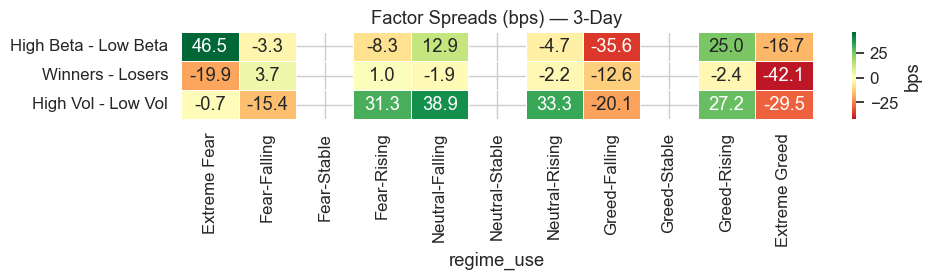

### 5-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed
High Beta - Low Beta,82.1,4.2,nan,-5.5,25.9,nan,-5.4,-49.1,nan,28.8,-34.6
Winners - Losers,-33.9,-17.9,nan,59.8,-16.3,nan,18.5,-6.3,nan,-11.3,-57.1
High Vol - Low Vol,13.8,-17.4,nan,45.8,74.6,nan,63.5,-11.7,nan,33.4,-58.3


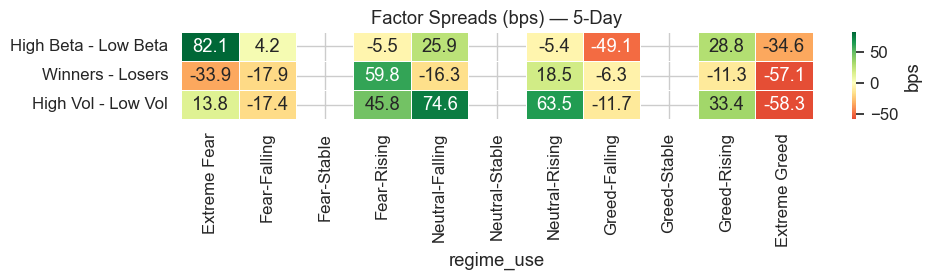

### 10-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed
High Beta - Low Beta,139.0,11.7,nan,30.4,56.3,nan,-19.6,-64.0,nan,28.8,-74.5
Winners - Losers,-44.3,-56.9,nan,95.3,-23.5,nan,111.4,23.7,nan,-20.8,-75.9
High Vol - Low Vol,50.8,-1.1,nan,144.2,130.6,nan,127.3,21.4,nan,31.0,-94.3


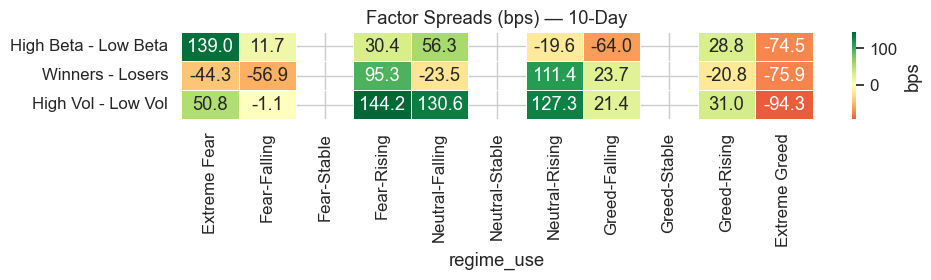

### 21-Day Returns

regime_use,Extreme Fear,Fear-Falling,Fear-Stable,Fear-Rising,Neutral-Falling,Neutral-Stable,Neutral-Rising,Greed-Falling,Greed-Stable,Greed-Rising,Extreme Greed
High Beta - Low Beta,214.5,23.6,nan,69.4,91.4,nan,37.8,-41.0,nan,-20.9,-144.3
Winners - Losers,-185.5,-84.6,nan,80.3,90.5,nan,302.6,7.2,nan,-27.2,-153.2
High Vol - Low Vol,174.4,18.8,nan,306.4,262.7,nan,306.5,136.6,nan,-1.6,-78.6


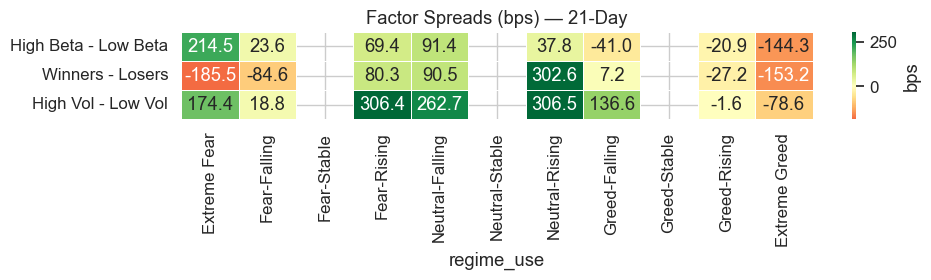

In [84]:
def ls_spread(data, group_col, long_label, short_label, ret_col):
    """Mean return spread: long minus short group, per regime."""
    tmp = data.dropna(subset=[ret_col, group_col]).copy()
    tmp['_ret'] = tmp[ret_col] * 10000
    g = tmp.groupby([group_col, 'regime_use'], observed=False)['_ret'].mean().unstack('regime_use')
    return (g.loc[long_label] - g.loc[short_label]).reindex(EXT_REGIME_ORDER)

for label, col in HORIZONS.items():
    display(Markdown(f'### {label} Returns'))

    spreads = pd.DataFrame({
        'High Beta - Low Beta': ls_spread(df, 'beta_group', 'High', 'Low', col),
        'Winners - Losers': ls_spread(df, 'mom_group', 'Winners', 'Losers', col),
        'High Vol - Low Vol': ls_spread(df, 'vol_group', 'High Vol', 'Low Vol', col),
    }).T

    display(spreads.style.background_gradient(cmap='RdYlGn', axis=None).format('{:.1f}'))

    fig, ax = plt.subplots(figsize=(10, 3))
    sns.heatmap(spreads, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
                ax=ax, linewidths=0.5, cbar_kws={'label': 'bps'})
    ax.set_title(f'Factor Spreads (bps) \u2014 {label}')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()